In [1]:
# ============================================================
# LIBRARIAT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Lexo dataset-in e pastruar
df = pd.read_csv("../data/processed/laliga_master.csv")

print("Dimensionet:", df.shape)
print()
print(df.head(3))

Dimensionet: (420, 33)

         Squad  MP   W   D  L  GF  GA  GD  Pts  Pts/MP  ... CS%  PKA  PKsv  \
0    Barcelona  38  25   9  4  73  29  44   84    2.21  ... NaN  NaN   NaN   
1  Real Madrid  38  25   5  8  71  32  39   80    2.11  ... NaN  NaN   NaN   
2   Villarreal  38  18  11  9  69  37  32   65    1.71  ... NaN  NaN   NaN   

   PKm  Age  Poss  Ast  PKatt  CrdY  CrdR  
0  NaN  NaN   NaN  NaN    NaN   NaN   NaN  
1  NaN  NaN   NaN  NaN    NaN   NaN   NaN  
2  NaN  NaN   NaN  NaN    NaN   NaN   NaN  

[3 rows x 33 columns]


In [2]:
# ============================================================
# STATISTIKA PERSHKRUESE
# ============================================================

# Statistikat bazë për kolonat kryesore
kolonat_bazë = ["W", "D", "L", "GF", "GA", "GD", "Pts", "Pts/MP"]

print("=== STATISTIKA PERSHKRUESE ===")
print(df[kolonat_bazë].describe().round(2))

=== STATISTIKA PERSHKRUESE ===
            W       D       L      GF      GA      GD     Pts  Pts/MP
count  420.00  420.00  420.00  420.00  420.00  420.00  420.00  420.00
mean    14.25    9.51   14.25   50.52   50.52    0.00   52.24    1.38
std      5.96    2.94    5.18   17.69   12.11   25.94   16.63    0.44
min      3.00    1.00    1.00   22.00   18.00  -64.00   16.00    0.42
25%     10.00    7.00   11.00   39.00   43.00  -17.00   41.00    1.08
50%     13.00    9.00   15.00   46.00   51.00   -6.00   48.00    1.26
75%     17.00   11.00   18.00   57.25   58.00   11.25   61.00    1.61
max     32.00   18.00   30.00  121.00   94.00   89.00  100.00    2.63


In [3]:
# ============================================================
# STATISTIKA PER EKIPET KRYESORE
# ============================================================

ekipet_kryesore = ["Real Madrid", "Barcelona", "Atletico Madrid",
                   "Athletic Club", "Villarreal", "Sevilla",
                   "Real Sociedad", "Valencia"]

# Mesatarja e pikëve dhe golave për sezon
stats_ekipet = df[df["Squad"].isin(ekipet_kryesore)].groupby("Squad")[["Pts","GF","GA","GD","W"]].mean().round(1)

# Rendit sipas pikëve
stats_ekipet = stats_ekipet.sort_values("Pts", ascending=False)

print("=== MESATARJA PER SEZON (2004-2025) ===")
print(stats_ekipet)

=== MESATARJA PER SEZON (2004-2025) ===
                  Pts    GF    GA    GD     W
Squad                                        
Barcelona        86.6  92.9  32.9  60.0  26.6
Real Madrid      84.9  88.3  36.5  51.8  26.2
Atletico Madrid  70.2  61.7  36.0  25.6  20.5
Sevilla          61.0  56.8  46.4  10.3  17.4
Villarreal       60.2  56.8  45.2  11.6  16.8
Valencia         57.4  54.4  47.0   7.5  15.7
Athletic Club    53.5  48.8  46.6   2.2  14.4
Real Sociedad    52.9  50.3  49.4   0.8  14.6


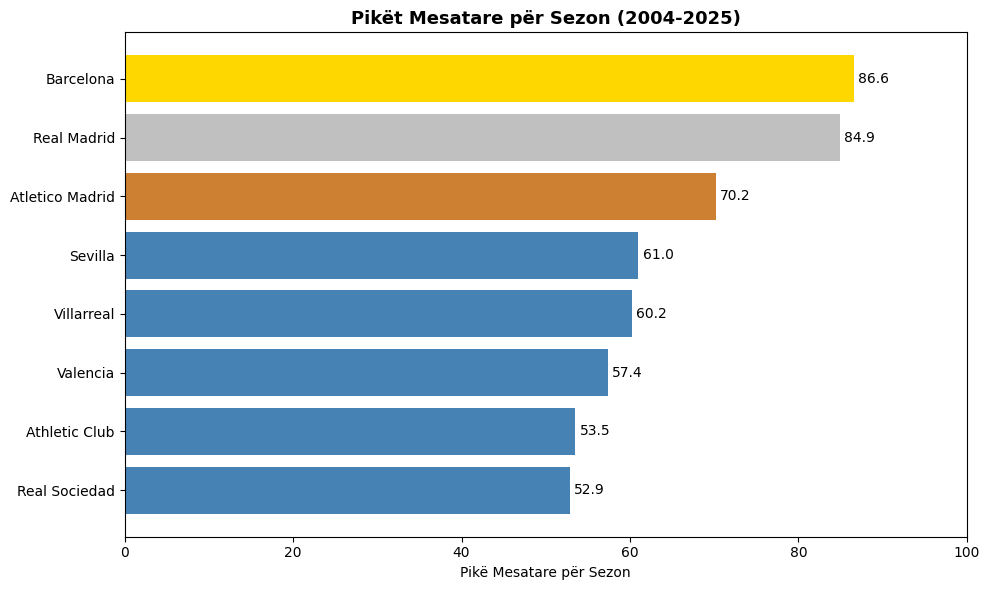

Grafiku u ruajt!


In [4]:
# ============================================================
# GRAFIK - PIKËT MESATARE PER EKIP
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Ngjyra speciale per top 3
ngjyrat = ["gold", "silver", "#CD7F32",  
           "steelblue", "steelblue", "steelblue", 
           "steelblue", "steelblue"]

bars = ax.barh(stats_ekipet.index, stats_ekipet["Pts"], color=ngjyrat)

# Shto vlerat ne fund te shtylave
for bar, val in zip(bars, stats_ekipet["Pts"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", fontsize=10)

ax.set_xlabel("Pikë Mesatare për Sezon")
ax.set_title("Pikët Mesatare për Sezon (2004-2025)", fontsize=13, fontweight="bold")
ax.set_xlim(0, 100)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../outputs/figures/01_pike_mesatare.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [5]:
# ============================================================
# DOMINANCA HISTORIKE - KUSH KA FITUAR ME SHUME TITUJ
# ============================================================

# Kampioni i çdo sezoni = ekipi me pikët maksimale
kampionet = df.groupby("sezoni").apply(
    lambda x: x.loc[x["Pts"].idxmax(), "Squad"]
).reset_index()
kampionet.columns = ["sezoni", "kampion"]

# Numëro titujt per ekip
titujt = kampionet["kampion"].value_counts().reset_index()
titujt.columns = ["ekipi", "titujt"]

print("=== TITUJT E LA LIGA (2004-2025) ===")
print(titujt)

=== TITUJT E LA LIGA (2004-2025) ===
             ekipi  titujt
0        Barcelona      12
1      Real Madrid       7
2  Atletico Madrid       2


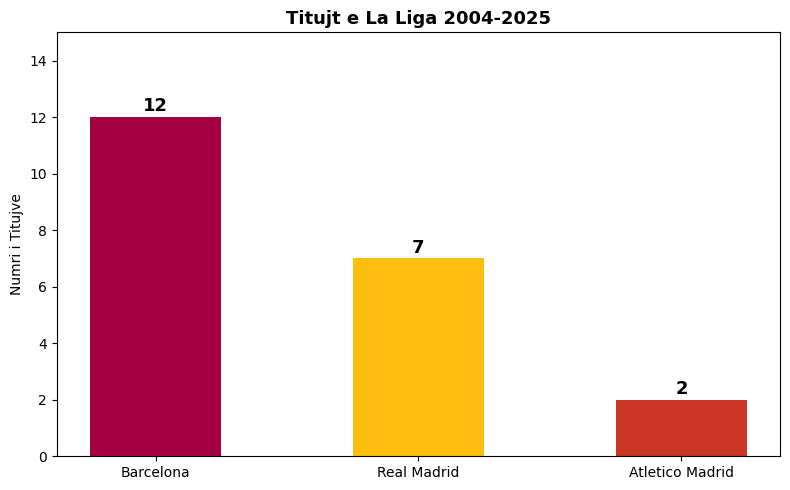

Grafiku u ruajt!


In [7]:
# ============================================================
# GRAFIK - TITUJT E LA LIGA
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ngjyrat = ["#A50044", "#FEBE10", "#CB3524"]  # Barça, Madrid, Atletico

bars = ax.bar(titujt["ekipi"], titujt["titujt"], color=ngjyrat, width=0.5)

# Shto numrin mbi shtyllat
for bar, val in zip(bars, titujt["titujt"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha="center", fontsize=13, fontweight="bold")

ax.set_ylabel("Numri i Titujve")
ax.set_title("Titujt e La Liga 2004-2025", fontsize=13, fontweight="bold")
ax.set_ylim(0, 15)

plt.tight_layout()
plt.savefig("../outputs/figures/02_titujt.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [8]:
# ============================================================
# TRENDI I PIKEVE TE KAMPIONIT NEPËR SEZONE
# ============================================================

# Merr pikët maksimale për çdo sezon
trendi = df.groupby("sezoni").agg(
    kampion  = ("Squad", lambda x: x.loc[df.loc[x.index, "Pts"].idxmax()]),
    pike_max = ("Pts", "max"),
    pike_min = ("Pts", "min")
).reset_index()

print(trendi)

       sezoni          kampion  pike_max  pike_min
0   2004-2005        Barcelona        84        28
1   2005-2006        Barcelona        82        24
2   2006-2007      Real Madrid        76        28
3   2007-2008      Real Madrid        85        26
4   2008-2009        Barcelona        87        33
5   2009-2010        Barcelona        99        34
6   2010-2011        Barcelona        96        30
7   2011-2012      Real Madrid       100        27
8   2012-2013        Barcelona       100        34
9   2013-2014  Atletico Madrid        90        25
10  2014-2015        Barcelona        94        20
11  2015-2016        Barcelona        91        32
12  2016-2017      Real Madrid        93        20
13  2017-2018        Barcelona        93        20
14  2018-2019        Barcelona        87        32
15  2019-2020      Real Madrid        87        25
16  2020-2021  Atletico Madrid        86        30
17  2021-2022      Real Madrid        86        31
18  2022-2023        Barcelona 

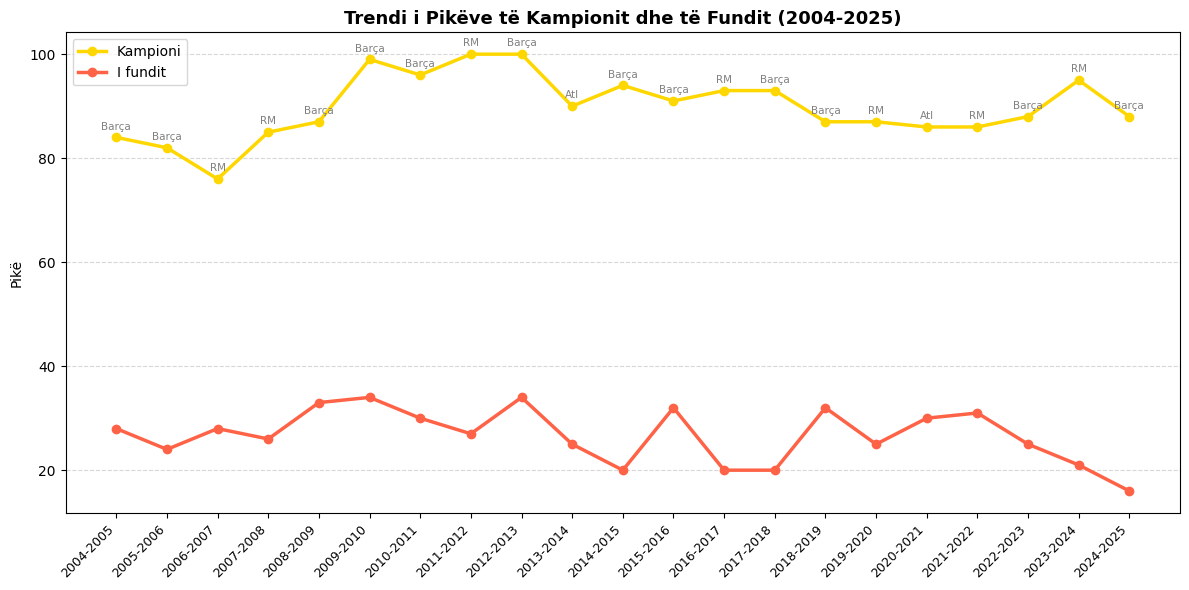

Grafiku u ruajt!


In [9]:
# ============================================================
# GRAFIK - TRENDI I PIKEVE NEPËR SEZONE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Linja e pikëve maksimale (kampioni)
ax.plot(trendi["sezoni"], trendi["pike_max"], 
        color="gold", linewidth=2.5, marker="o", markersize=6, label="Kampioni")

# Linja e pikëve minimale (i fundit)
ax.plot(trendi["sezoni"], trendi["pike_min"], 
        color="tomato", linewidth=2.5, marker="o", markersize=6, label="I fundit")

# Shto emrin e kampionit mbi çdo pikë
for i, row in trendi.iterrows():
    emri_shkurter = row["kampion"].replace("Real Madrid", "RM").replace("Barcelona", "Barça").replace("Atletico Madrid", "Atl")
    ax.text(i, row["pike_max"] + 1.5, emri_shkurter, 
            ha="center", fontsize=7.5, color="gray")

ax.set_xticks(range(len(trendi)))
ax.set_xticklabels(trendi["sezoni"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Pikë")
ax.set_title("Trendi i Pikëve të Kampionit dhe të Fundit (2004-2025)", 
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/figures/03_trendi_pikeve.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

C:\Users\user\AppData\Local\Temp\ipykernel_20440\3729416230.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_boxplot, labels=ekipet_kryesore, patch_artist=True,


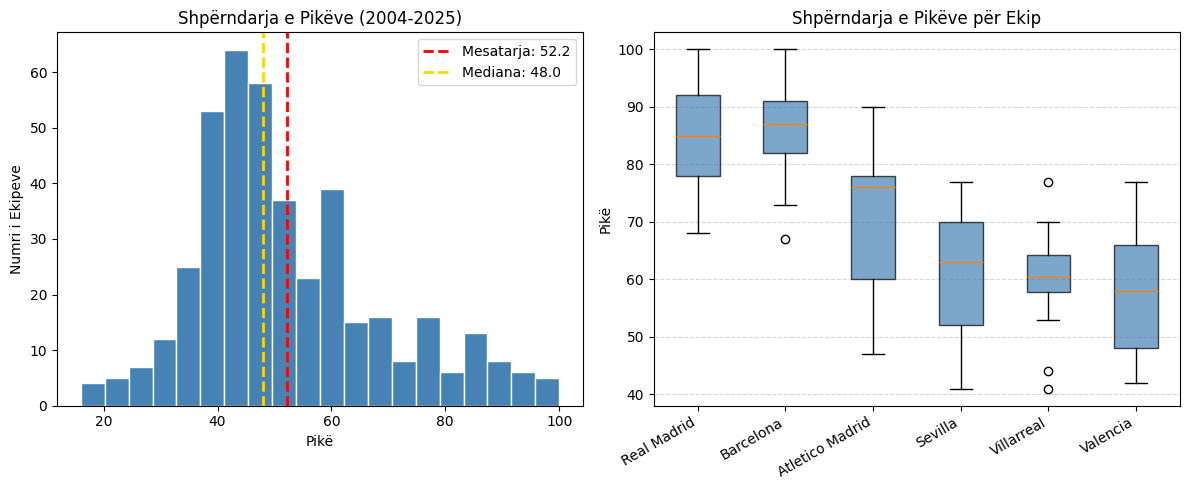

Grafiku u ruajt!


In [10]:
# ============================================================
# SHPËRNDARJA E PIKEVE
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Histogram ---
ax1.hist(df["Pts"], bins=20, color="steelblue", edgecolor="white")
ax1.axvline(df["Pts"].mean(), color="red", linestyle="--", linewidth=2, label=f'Mesatarja: {df["Pts"].mean():.1f}')
ax1.axvline(df["Pts"].median(), color="gold", linestyle="--", linewidth=2, label=f'Mediana: {df["Pts"].median():.1f}')
ax1.set_xlabel("Pikë")
ax1.set_ylabel("Numri i Ekipeve")
ax1.set_title("Shpërndarja e Pikëve (2004-2025)")
ax1.legend()

# --- Boxplot per ekipet kryesore ---
ekipet_kryesore = ["Real Madrid", "Barcelona", "Atletico Madrid",
                   "Sevilla", "Villarreal", "Valencia"]

data_boxplot = [df[df["Squad"] == ekip]["Pts"].values for ekip in ekipet_kryesore]

ax2.boxplot(data_boxplot, labels=ekipet_kryesore, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.7))
ax2.set_xticklabels(ekipet_kryesore, rotation=30, ha="right")
ax2.set_ylabel("Pikë")
ax2.set_title("Shpërndarja e Pikëve për Ekip")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/figures/04_shperndarje_pikeve.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [11]:
# ============================================================
# HEATMAP - KORRELACIONI MES VARIABLAVE
# ============================================================

# Kolonat kryesore për korrelacion
kolonat = ["Pts", "W", "GF", "GA", "GD", "Sh", "SoT", "Save%", "CS"]

# Llogarit korrelacionin
korr = df[kolonat].corr().round(2)

print("=== MATRICA E KORRELACIONIT ===")
print(korr)

=== MATRICA E KORRELACIONIT ===
        Pts     W    GF    GA    GD    Sh   SoT  Save%    CS
Pts    1.00  0.99  0.88 -0.77  0.96  0.65  0.74   0.58  0.76
W      0.99  1.00  0.88 -0.72  0.94  0.67  0.76   0.54  0.73
GF     0.88  0.88  1.00 -0.50  0.91  0.78  0.89   0.32  0.43
GA    -0.77 -0.72 -0.50  1.00 -0.81 -0.36 -0.38  -0.77 -0.84
GD     0.96  0.94  0.91 -0.81  1.00  0.70  0.78   0.60  0.71
Sh     0.65  0.67  0.78 -0.36  0.70  1.00  0.90   0.20  0.33
SoT    0.74  0.76  0.89 -0.38  0.78  0.90  1.00   0.23  0.38
Save%  0.58  0.54  0.32 -0.77  0.60  0.20  0.23   1.00  0.65
CS     0.76  0.73  0.43 -0.84  0.71  0.33  0.38   0.65  1.00


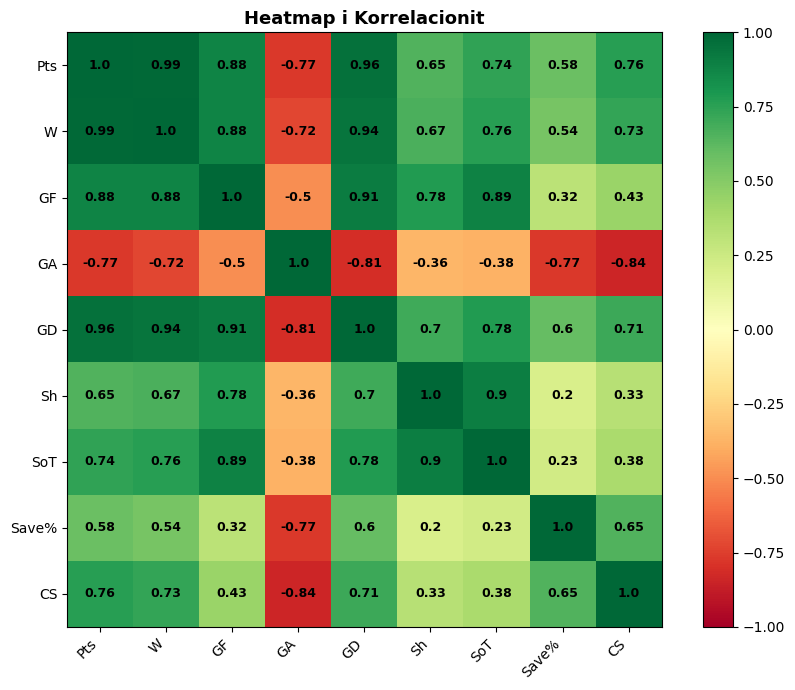

Grafiku u ruajt!


In [12]:
# ============================================================
# HEATMAP - KORRELACIONI
# ============================================================
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(9, 7))

# Vizualizimi i matricës
im = ax.imshow(korr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

# Shto etiketat
ax.set_xticks(range(len(kolonat)))
ax.set_yticks(range(len(kolonat)))
ax.set_xticklabels(kolonat, rotation=45, ha="right")
ax.set_yticklabels(kolonat)

# Shto vlerat brenda
for i in range(len(kolonat)):
    for j in range(len(kolonat)):
        ax.text(j, i, str(korr.iloc[i, j]),
                ha="center", va="center", fontsize=9, fontweight="bold")

ax.set_title("Heatmap i Korrelacionit", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/05_korrelacioni.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

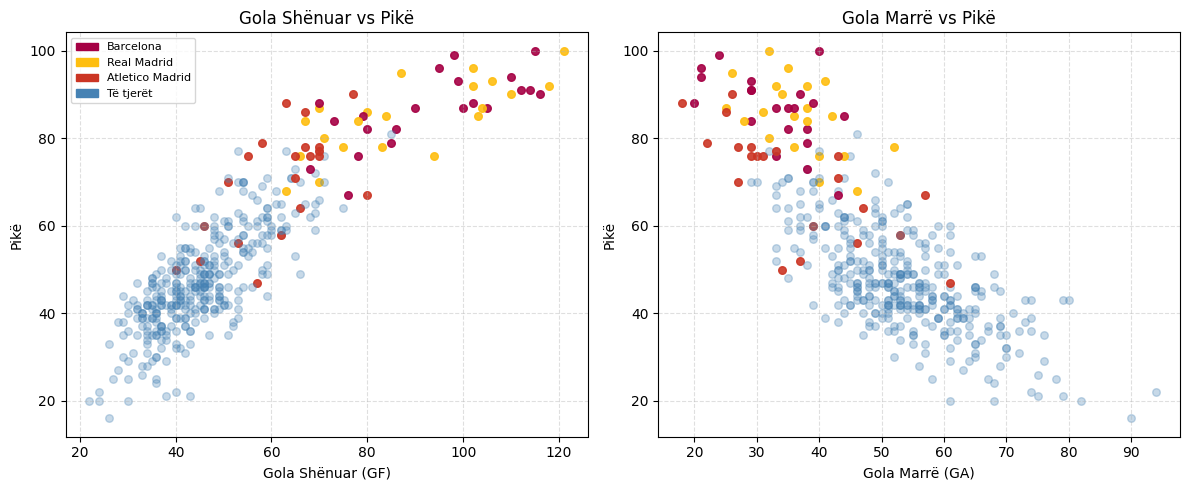

Grafiku u ruajt!


In [13]:
# ============================================================
# SULMI VS MBROJTJA - SCATTER PLOT
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Ngjyra per ekipet kryesore
ngjyrat_ekip = {
    "Barcelona"      : "#A50044",
    "Real Madrid"    : "#FEBE10",
    "Atletico Madrid": "#CB3524"
}

# --- Grafiku 1: Gola Shënuar vs Pikë ---
for _, row in df.iterrows():
    ngjyra = ngjyrat_ekip.get(row["Squad"], "steelblue")
    alpha  = 0.9 if row["Squad"] in ngjyrat_ekip else 0.3
    ax1.scatter(row["GF"], row["Pts"], color=ngjyra, alpha=alpha, s=30)

ax1.set_xlabel("Gola Shënuar (GF)")
ax1.set_ylabel("Pikë")
ax1.set_title("Gola Shënuar vs Pikë")
ax1.grid(linestyle="--", alpha=0.4)

# --- Grafiku 2: Gola Marrë vs Pikë ---
for _, row in df.iterrows():
    ngjyra = ngjyrat_ekip.get(row["Squad"], "steelblue")
    alpha  = 0.9 if row["Squad"] in ngjyrat_ekip else 0.3
    ax2.scatter(row["GA"], row["Pts"], color=ngjyra, alpha=alpha, s=30)

ax2.set_xlabel("Gola Marrë (GA)")
ax2.set_ylabel("Pikë")
ax2.set_title("Gola Marrë vs Pikë")
ax2.grid(linestyle="--", alpha=0.4)

# Legjenda
from matplotlib.patches import Patch
legjenda = [Patch(color="#A50044", label="Barcelona"),
            Patch(color="#FEBE10", label="Real Madrid"),
            Patch(color="#CB3524", label="Atletico Madrid"),
            Patch(color="steelblue", label="Të tjerët")]
ax1.legend(handles=legjenda, fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/06_sulmi_vs_mbrojtja.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")